<a href="https://colab.research.google.com/github/nam5588/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch

In [2]:
import torch
print(torch.__version__)

2.11.0+cpu


In [3]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


In [4]:
scalar = torch.tensor(5)  #0D
print("scalar: ", scalar)
print("Shape: ", scalar.shape)
print("Dimension: ", scalar.ndim)
print("Size: ", scalar.size())

scalar:  tensor(5)
Shape:  torch.Size([])
Dimension:  0
Size:  torch.Size([])


In [5]:
vector = torch.tensor([1,2,3])  #1D
print("vector: ", vector)
print("Shape: ", vector.shape)
print("Dimension: ", vector.ndim)
print("Size: ", vector.size())

vector:  tensor([1, 2, 3])
Shape:  torch.Size([3])
Dimension:  1
Size:  torch.Size([3])


In [6]:
MATRIX = torch.tensor([[1,2,3],
                      [5,7,9]])  #2D
print("MATRIX: ", MATRIX)
print("Shape: ", MATRIX.shape)
print("Dimension: ", MATRIX.ndim)
print("Size: ", MATRIX.size())

MATRIX:  tensor([[1, 2, 3],
        [5, 7, 9]])
Shape:  torch.Size([2, 3])
Dimension:  2
Size:  torch.Size([2, 3])


In [7]:
tensor3d = torch.stack([MATRIX, MATRIX + 10])  #3D
print("tensor3d: ", tensor3d)
print("Shape: ", tensor3d.shape)  # [2,2,3] or [C] | 2 matries => channels | 2 rows im each matrix | 3 columns ineach matrix (height, widht)
print("Dimension: ", tensor3d.ndim)
print("Size: ", tensor3d.size())

tensor3d:  tensor([[[ 1,  2,  3],
         [ 5,  7,  9]],

        [[11, 12, 13],
         [15, 17, 19]]])
Shape:  torch.Size([2, 2, 3])
Dimension:  3
Size:  torch.Size([2, 2, 3])


In [8]:
random_numbers = torch.rand(2, 3) # 0 ~ 1
print("Random Numbers: ", random_numbers)
print("Data Type:", random_numbers.dtype)

print("Device of random numbers:", random_numbers.device)

Random Numbers:  tensor([[0.6726, 0.7550, 0.3448],
        [0.3426, 0.4843, 0.2833]])
Data Type: torch.float32
Device of random numbers: cpu


In [9]:
print("Zeros:", torch.zeros(3,3))

Zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [10]:
print("Ones:", torch.ones(2,4))

Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [11]:
x = torch.tensor([[1,2],
                 [3,4]])

y = torch.tensor([[5,6],
                 [7,8]])

# Elementa-wise additon
print("Addidtion:", x+y)
print("================")

# Elementa-wise multiplcation
print("Mutilication:", x * y)
print("================")

# Matrix multiplcation
print("Mutilication:", x @ y)

Addidtion: tensor([[ 6,  8],
        [10, 12]])
Mutilication: tensor([[ 5, 12],
        [21, 32]])
Mutilication: tensor([[19, 22],
        [43, 50]])


# **Model-Test**

In [12]:
import torch
from torch import nn      # barcha nn qurish uchun kerakli blocklarni yuklaydi
import matplotlib.pyplot as plt

print(torch.__version__)

2.11.0+cpu


In [13]:
# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [17]:
# Create weight and bais
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and Y  (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # unsqueeze bolmasa errorlar kech chiqadi
y = weight * X + bias

# Liner Regression: y = wx + b     [ FORMULA ]

print("X:", X)
print("\n y:", y)

#Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

 y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
 

(40, 40, 10, 10)

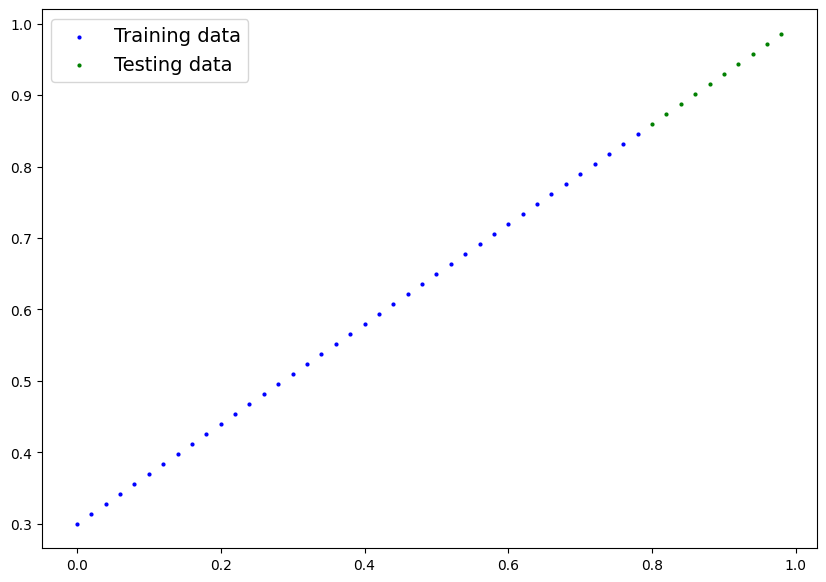

In [18]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Prediction")

    plt.legend(prop={"size": 14})

plot_predictions()

In [19]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
     super().__init__()
     # Use nn.Linear() for creating the modal parameters
     self.linear_layer = nn.Linear(in_features=1,
                                   out_features=1)

  # Define the forward computatuion (input data X flows trough nn.Linear())
  def forward(self, x: torch.Tensor) -> torch.Tensor:
     return self.linear_layer(x)
# Set the manual send when creating the model (this isn't always needed but is used for demonstrative purpores)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [20]:
# Create loss function
loss_fn = nn.L1Loss() # MAE

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

Text(0.5, 1.0, 'Untrained predictions (red dots: random guesses)')

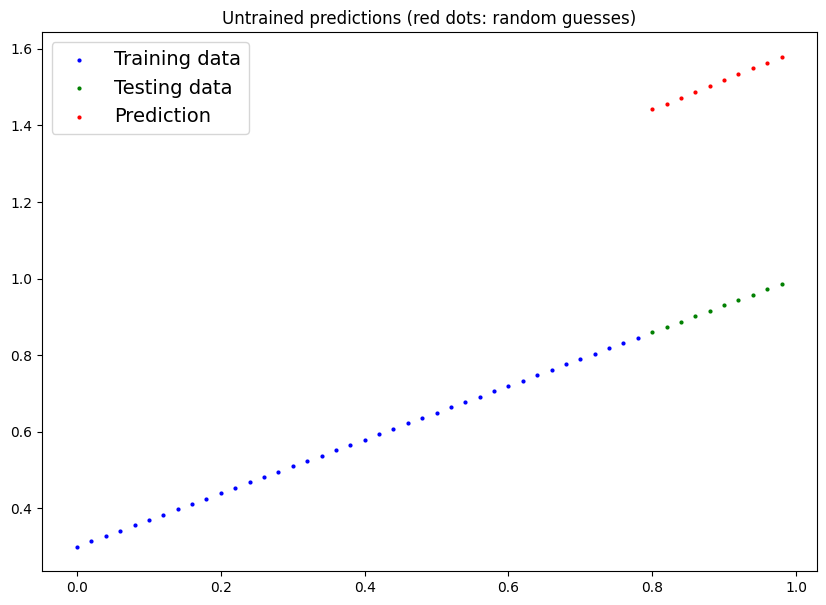

In [21]:
# See model's untrained  rediction (on test set)
model_1.eval()
with torch.inference_mode():
    y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)
plt.title("Untrained predictions (red dots: random guesses)")


In [22]:
epochs = 1000

# Mavjuda devicega otish
# Busiz error ehtimoli bor
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)
model_1 = model_1.to(device)

for epoch in range(epochs):
    model_1.train() # train mode is on by def. after construction

    # 1. Forward pass - keyingisi qoyib beradi
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss Backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():  # 1. Forward pass
        test_pred = model_1(X_test)

        # 2. Calculate loss
        test_loss = loss_fn(test_pred, y_test)
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss} | Test loss: {test_loss}")

#

Epoch: 0 | Train Loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 100 | Train Loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 200 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 300 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 400 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 500 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 600 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 700 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 800 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 900 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904


In [23]:
# Turn Model into evaluation mode

model_1.eval()

# Make prediction with test data

with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

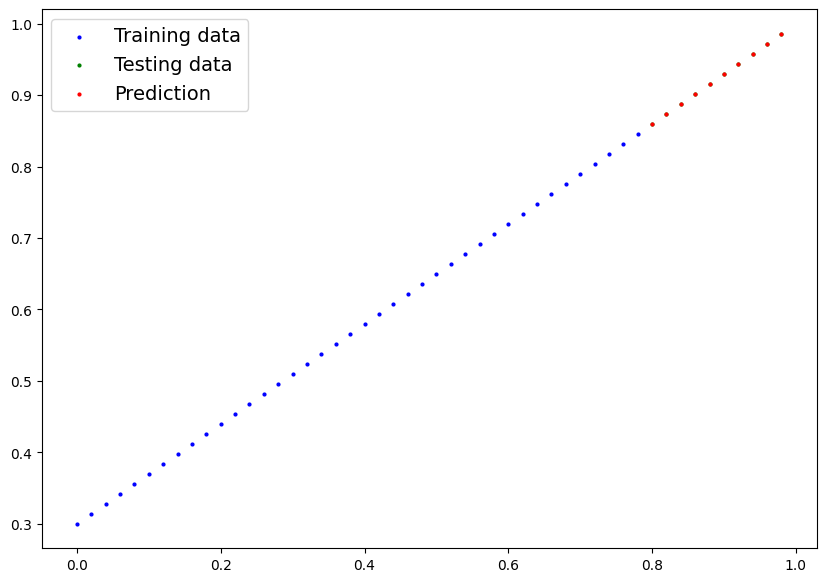

In [24]:
# Put data on the CPU and plot it
plot_predictions(predictions=y_preds)

In [25]:
torch.save(model_1.state_dict(), 'trained_model.pth')

In [26]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load('/content/trained_model.pth'))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)